# EmotionCLIP-ReID JupyterHub Runbook

Notebook này chuẩn bị FER2013 7 lớp, tạo landmark offline một lần, train và lưu toàn bộ log/ảnh theo một `RUN_ID` có ngày giờ chạy. Mỗi lần chạy tạo `OUTPUT_ROOT/<run_id>/` riêng; notebook không dò thư mục `latest` và không ghi đè run cũ.


## 0. Kernel khuyến nghị

Chọn kernel **Python 3.10** có **PyTorch CUDA**. Repo đang dùng `environment_emotionclip_cuda.yml` với `python=3.10` và `pytorch-cuda=12.1`; CUDA 12.1 wheel vẫn chạy được trên driver mới hơn như CUDA 13.0. Nếu JupyterHub chỉ có kernel Python 3.9 thì vẫn có thể thử, nhưng Python 3.10 là đường ít lỗi nhất.

In [1]:
# Chạy cell này trong đúng kernel bạn định train.
# Cell này cài package vào CHÍNH Python của kernel qua sys.executable.
import importlib
import importlib.util
import os
import site
import os
import subprocess
import sys
from pathlib import Path

INSTALL_TORCH = True
TORCH_INDEX_URL = 'https://download.pytorch.org/whl/cu121'

print('Python executable:', sys.executable)
print('Python version:', sys.version)
print('User site enabled:', site.ENABLE_USER_SITE)
print('User site:', site.getusersitepackages())
print('PYTHONNOUSERSITE:', os.environ.get('PYTHONNOUSERSITE'))

base_packages = [
    'numpy',
    'pillow',
    'pyyaml',
    'tqdm',
    'datasets',
    'ftfy',
    'regex',
    'matplotlib',
]
print('Installing/checking base packages into kernel Python...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--user', '--upgrade', *base_packages])

if INSTALL_TORCH:
    try:
        import torch
        print('torch already installed:', torch.__version__)
    except ModuleNotFoundError:
        print('Torch missing. Installing PyTorch CUDA 12.1 wheel into this kernel...')
        subprocess.check_call([
            sys.executable,
            '-m',
            'pip',
            'install',
            '--user',
            '--upgrade',
            '--no-cache-dir',
            'torch',
            'torchvision',
            'torchaudio',
            '--index-url',
            TORCH_INDEX_URL,
        ])
        importlib.invalidate_caches()

try:
    import torch
except ModuleNotFoundError as exc:
    print('Torch vẫn chưa import được trong kernel này.')
    print('pip show torch:')
    subprocess.run([sys.executable, '-m', 'pip', 'show', 'torch'], check=False)
    print('find_spec(torch):', importlib.util.find_spec('torch'))
    print('sys.path:')
    for item in sys.path:
        print('  ', item)
    print('Hãy restart kernel. Nếu vẫn lỗi, chạy thủ công:')
    print(f'{sys.executable} -m pip install --user --upgrade --no-cache-dir torch torchvision torchaudio --index-url {TORCH_INDEX_URL}')
    raise

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))


Python executable: /opt/tljh/user/envs/py310/bin/python
Python version: 3.10.19 | packaged by conda-forge | (main, Jan 26 2026, 23:45:08) [GCC 14.3.0]
User site enabled: True
User site: /home/jupyter-hault/.local/lib/python3.10/site-packages
PYTHONNOUSERSITE: None
Installing/checking base packages into kernel Python...
torch already installed: 2.5.1+cu121
torch: 2.5.1+cu121
cuda available: True
gpu: Tesla T4


## 0.1. Clone hoặc cập nhật đúng branch `old_branch`

Cell dùng `git clone -b old_branch --single-branch` cho máy mới. Nếu repo đã tồn tại, cell fetch, checkout và fast-forward đúng branch; lỗi Git sẽ dừng ngay thay vì âm thầm chạy nhầm code.


In [2]:
from pathlib import Path
import os
import subprocess

JUPYTER_WORKSPACE = Path('/home/jupyter-hault')
REPO_DIR = JUPYTER_WORKSPACE / 'EmotionCLIP-ReID'
GIT_REPO_URL = 'https://github.com/haulth/EmotionCLIP-ReID.git'
REPO_BRANCH = 'old_branch'

JUPYTER_WORKSPACE.mkdir(parents=True, exist_ok=True)
if (REPO_DIR / '.git').exists():
    commands = [
        ['git', '-C', str(REPO_DIR), 'fetch', 'origin', REPO_BRANCH],
        ['git', '-C', str(REPO_DIR), 'checkout', REPO_BRANCH],
        ['git', '-C', str(REPO_DIR), 'pull', '--ff-only', 'origin', REPO_BRANCH],
    ]
else:
    commands = [[
        'git', 'clone', '-b', REPO_BRANCH, '--single-branch', GIT_REPO_URL, str(REPO_DIR)
    ]]

for command in commands:
    print('Running:', ' '.join(command))
    completed = subprocess.run(command, text=True, capture_output=True, check=True)
    if completed.stdout.strip():
        print(completed.stdout.strip())

os.chdir(REPO_DIR)
REPO_OVERRIDE = REPO_DIR
branch = subprocess.check_output(
    ['git', '-C', str(REPO_DIR), 'branch', '--show-current'], text=True
).strip()
assert branch == REPO_BRANCH, f'Expected {REPO_BRANCH}, got {branch}'
print('Repo:', Path.cwd())
print('Branch:', branch)
print('Has train_emotionclip.py:', (Path.cwd() / 'train_emotionclip.py').exists())
print('Has landmark builder:', (Path.cwd() / 'tools/build_face_landmark_artifacts.py').exists())


Running: git -C /home/jupyter-hault/EmotionCLIP-ReID fetch origin old_branch
Running: git -C /home/jupyter-hault/EmotionCLIP-ReID checkout old_branch
Your branch is up to date with 'origin/old_branch'.
Running: git -C /home/jupyter-hault/EmotionCLIP-ReID pull --ff-only origin old_branch
Already up to date.
Repo: /home/jupyter-hault/EmotionCLIP-ReID
Branch: old_branch
Has train_emotionclip.py: True
Has landmark builder: True


In [3]:
from pathlib import Path
import os

# Nếu auto-detect không thấy repo, điền đường dẫn repo của bạn vào đây, ví dụ:
# Work path JupyterHub của bạn:
JUPYTER_WORKSPACE = Path('/home/jupyter-hault')
REPO_OVERRIDE = JUPYTER_WORKSPACE / 'EmotionCLIP-ReID'

def find_repo_root(start: Path) -> Path:
    if REPO_OVERRIDE is not None:
        repo = Path(REPO_OVERRIDE).expanduser().resolve()
        if (repo / 'train_emotionclip.py').exists() and (repo / 'tools').exists():
            return repo
        raise FileNotFoundError(f'REPO_OVERRIDE không đúng: {repo}')

    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'train_emotionclip.py').exists() and (candidate / 'tools').exists():
            return candidate

    search_roots = [Path.home(), Path('/home'), Path('/mnt/e/Source')]
    seen = set()
    for root in search_roots:
        try:
            root = root.resolve()
        except FileNotFoundError:
            continue
        if root in seen or not root.exists():
            continue
        seen.add(root)
        try:
            for marker in root.rglob('train_emotionclip.py'):
                candidate = marker.parent
                if (candidate / 'tools/download_hf_emotion_dataset.py').exists():
                    return candidate
        except PermissionError:
            continue

    raise FileNotFoundError(
        'Không tìm thấy repo root chứa train_emotionclip.py. '
        'Hãy set REPO_OVERRIDE ở cell này thành đường dẫn thư mục EmotionCLIP-ReID.'
    )

REPO = find_repo_root(Path.cwd())
os.chdir(REPO)
print('Repo:', REPO)
print('Current working directory:', Path.cwd())
print('Has train_emotionclip.py:', (REPO / 'train_emotionclip.py').exists())
print('Has downloader:', (REPO / 'tools/download_hf_emotion_dataset.py').exists())


Repo: /home/jupyter-hault/EmotionCLIP-ReID
Current working directory: /home/jupyter-hault/EmotionCLIP-ReID
Has train_emotionclip.py: True
Has downloader: True


## 1. Kiểm tra/cài package tối thiểu

Nếu JupyterHub đã có environment `emotionclip`, cell này chỉ kiểm tra. Nếu thiếu package nhẹ cho data export, nó sẽ cài qua `pip` trong kernel hiện tại. PyTorch/CUDA nên được cài bằng conda theo `environment_emotionclip_cuda.yml` trên server của bạn.

In [4]:
import importlib.util
import subprocess
import sys

for pkg in ['datasets', 'PIL', 'yaml', 'tqdm', 'ftfy', 'regex']:
    print(pkg, 'OK' if importlib.util.find_spec(pkg) else 'MISSING')

missing = []
if importlib.util.find_spec('datasets') is None:
    missing.append('datasets')
if importlib.util.find_spec('PIL') is None:
    missing.append('pillow')
if importlib.util.find_spec('tqdm') is None:
    missing.append('tqdm')
if importlib.util.find_spec('ftfy') is None:
    missing.append('ftfy')
if importlib.util.find_spec('regex') is None:
    missing.append('regex')

if missing:
    print('Installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

try:
    import torch
    print('torch:', torch.__version__, 'cuda:', torch.cuda.is_available())
except Exception as exc:
    print('Torch is not ready in this kernel:', exc)

datasets OK
PIL OK
yaml OK
tqdm OK
ftfy OK
regex OK
torch: 2.5.1+cu121 cuda: True


## 1.1. Logic training hiện tại

FER2013 được chuẩn hóa về 7 lớp canonical. `Training` dùng để train, `PublicTest` dùng làm validation, còn `PrivateTest` luôn là test sealed; test không được dùng để chọn checkpoint hoặc hiệu chỉnh.

Stage 1 học prompt/text descriptor. Stage 2 tối ưu classification, image-text alignment và reliability tách rời. Landmark được tạo offline thành JSON detector-agnostic; baseline `topk` có thể đọc manifest anatomy nhưng không dùng landmark cho đến khi bật routing/geometry tương ứng.


In [5]:
CANONICAL_EMOTIONS = ('anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise', 'neutral')
FER2013_LABELS = ('Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral')
label_rows = [{'emotion_id': i, 'emotion': e, 'fer2013_label': f} for i, (e, f) in enumerate(zip(CANONICAL_EMOTIONS, FER2013_LABELS))]
label_rows


[{'emotion_id': 0, 'emotion': 'anger', 'fer2013_label': 'Angry'},
 {'emotion_id': 1, 'emotion': 'disgust', 'fer2013_label': 'Disgust'},
 {'emotion_id': 2, 'emotion': 'fear', 'fer2013_label': 'Fear'},
 {'emotion_id': 3, 'emotion': 'happiness', 'fer2013_label': 'Happy'},
 {'emotion_id': 4, 'emotion': 'sadness', 'fer2013_label': 'Sad'},
 {'emotion_id': 5, 'emotion': 'surprise', 'fer2013_label': 'Surprise'},
 {'emotion_id': 6, 'emotion': 'neutral', 'fer2013_label': 'Neutral'}]

## 2. Tải dataset và tạo manifest

Dataset mặc định: `Aaryan333/fer2013_train_publicTest_privateTest`. Nó có 7 cảm xúc cơ bản theo thứ tự tương thích repo: anger, disgust, fear, happiness, sadness, surprise, neutral.

In [6]:
RUN_FULL = True  
DATASET_ID = 'Aaryan333/fer2013_train_publicTest_privateTest'

# Data sẽ được ghi vào đúng working directory hiện tại của kernel.
# Nếu cell Repo tìm được repo thì Path.cwd() là repo root.
# Nếu không có repo trên JupyterHub, Path.cwd() là workspace hiện tại của kernel.
KERNEL_WORKSPACE = Path.cwd().resolve()

if RUN_FULL:
    DATA_ROOT = KERNEL_WORKSPACE / 'data/hf_fer2013'
    MAX_SAMPLES = -1
else:
    DATA_ROOT = KERNEL_WORKSPACE / 'data/hf_fer2013_smoke'
    MAX_SAMPLES = 200

MANIFEST = DATA_ROOT / 'manifest.jsonl'
IMAGES_ROOT = DATA_ROOT / 'images'
print('KERNEL_WORKSPACE:', KERNEL_WORKSPACE)
print('DATA_ROOT:', DATA_ROOT)
print('MANIFEST:', MANIFEST)
print('IMAGES_ROOT:', IMAGES_ROOT)
print('MAX_SAMPLES per HF split:', MAX_SAMPLES)


KERNEL_WORKSPACE: /home/jupyter-hault/EmotionCLIP-ReID
DATA_ROOT: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013
MANIFEST: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/manifest.jsonl
IMAGES_ROOT: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/images
MAX_SAMPLES per HF split: -1


In [7]:
import json
import os
import subprocess
import sys
from collections import Counter
from pathlib import Path

# Cell này tải data TRÊN SERVER JUPYTERHUB.
# Nếu data đã tồn tại thì bỏ qua tải lại. Đặt FORCE_DOWNLOAD = True để tải/ghi lại.
FORCE_DOWNLOAD = False

try:
    REPO
except NameError:
    REPO = None

if REPO is not None:
    try:
        os.chdir(REPO)
    except Exception:
        pass

DATA_ROOT = Path(DATA_ROOT).expanduser().resolve()
MANIFEST = DATA_ROOT / 'manifest.jsonl'
IMAGES_ROOT = DATA_ROOT / 'images'
print('Kernel cwd before download:', Path.cwd().resolve())
print('DATA_ROOT absolute:', DATA_ROOT)
print('MANIFEST absolute:', MANIFEST)
print('IMAGES_ROOT absolute:', IMAGES_ROOT)

records = []
if MANIFEST.exists() and IMAGES_ROOT.exists() and not FORCE_DOWNLOAD:
    print('Data đã tồn tại, bỏ qua tải lại.')
    with MANIFEST.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    print('num records:', len(records))
    print('splits:', Counter(r['split'] for r in records))
    print('classes:', Counter(r['emotion'] for r in records))
else:
    download_script = Path('tools/download_hf_emotion_dataset.py')
    if download_script.exists():
        cmd = [
            sys.executable,
            str(download_script),
            '--dataset', DATASET_ID,
            '--output-root', str(DATA_ROOT),
            '--max-samples-per-split', str(MAX_SAMPLES),
        ]
        print('Running repo downloader:', ' '.join(cmd))
        result = subprocess.run(cmd, text=True, capture_output=True)
        print(result.stdout)
        if result.returncode != 0:
            print(result.stderr)
            raise subprocess.CalledProcessError(result.returncode, cmd)

        with MANIFEST.open('r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
        print('num records:', len(records))
        print('splits:', Counter(r['split'] for r in records))
        print('classes:', Counter(r['emotion'] for r in records))
    else:
        print('Không thấy repo downloader, tải data trực tiếp trong notebook trên server JupyterHub.')
        print('cwd:', Path.cwd())
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--user', '-q', 'datasets', 'pillow', 'tqdm'])

        from datasets import load_dataset

        CANONICAL_EMOTIONS = ('anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise', 'neutral')
        EMOTION_TO_ID = {name: idx for idx, name in enumerate(CANONICAL_EMOTIONS)}
        ALIASES = {
            'angry': 'anger', 'anger': 'anger',
            'disgust': 'disgust', 'disgusted': 'disgust',
            'fear': 'fear', 'fearful': 'fear',
            'happy': 'happiness', 'happiness': 'happiness',
            'sad': 'sadness', 'sadness': 'sadness',
            'surprise': 'surprise', 'surprised': 'surprise',
            'neutral': 'neutral',
        }

        def split_name(name):
            name = str(name).lower()
            if name in {'train', 'training'}:
                return 'train'
            if name in {'validation', 'valid', 'val', 'publictest'}:
                return 'val'
            if name in {'test', 'privatetest'}:
                return 'test'
            return name

        def normalize_label(value, label_feature=None):
            if label_feature is not None and hasattr(label_feature, 'int2str'):
                try:
                    value = label_feature.int2str(int(value))
                except Exception:
                    pass
            text = str(value).strip().lower().replace('-', '_').replace(' ', '_')
            if text.isdigit():
                return CANONICAL_EMOTIONS[int(text)]
            return ALIASES[text]

        DATA_ROOT.mkdir(parents=True, exist_ok=True)
        ds = load_dataset(DATASET_ID, streaming=True)
        counts = {}
        for hf_split, split_data in ds.items():
            split = split_name(hf_split)
            try:
                split_data = split_data.shuffle(seed=1234, buffer_size=10000)
            except Exception:
                pass
            label_feature = getattr(split_data, 'features', {}).get('label')
            for idx, sample in enumerate(split_data):
                if MAX_SAMPLES is not None and int(MAX_SAMPLES) >= 0 and idx >= int(MAX_SAMPLES):
                    break
                emotion = normalize_label(sample['label'], label_feature)
                rel_path = Path(split) / emotion / f'{hf_split}_{idx:06d}.jpg'
                out_path = IMAGES_ROOT / rel_path
                out_path.parent.mkdir(parents=True, exist_ok=True)
                sample['image'].convert('RGB').save(out_path)
                records.append({
                    'image_path': rel_path.as_posix(),
                    'emotion': emotion,
                    'emotion_id': EMOTION_TO_ID[emotion],
                    'split': split,
                    'source': DATASET_ID,
                    'hf_split': hf_split,
                    'hf_index': idx,
                })
                counts[split] = counts.get(split, 0) + 1

        with MANIFEST.open('w', encoding='utf-8') as f:
            for record in records:
                f.write(json.dumps(record, ensure_ascii=False) + '\n')

        print(f'Wrote {len(records)} records to {MANIFEST}')
        print(f'Images root: {IMAGES_ROOT}')
        print(f'Split counts: {counts}')
        print('classes:', Counter(r['emotion'] for r in records))


Kernel cwd before download: /home/jupyter-hault/EmotionCLIP-ReID
DATA_ROOT absolute: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013
MANIFEST absolute: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/manifest.jsonl
IMAGES_ROOT absolute: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/images
Data đã tồn tại, bỏ qua tải lại.
num records: 35887
splits: Counter({'train': 28709, 'test': 3589, 'val': 3589})
classes: Counter({'happiness': 8989, 'neutral': 6198, 'sadness': 6077, 'fear': 5121, 'anger': 4953, 'surprise': 4002, 'disgust': 547})


In [8]:
import json
from collections import Counter

records = []
with MANIFEST.open('r', encoding='utf-8') as handle:
    for line in handle:
        records.append(json.loads(line))

print('num records:', len(records))
print('splits:', Counter(r['split'] for r in records))
print('classes:', Counter(r['emotion'] for r in records))
print('first record:', records[0])

num records: 35887
splits: Counter({'train': 28709, 'test': 3589, 'val': 3589})
classes: Counter({'happiness': 8989, 'neutral': 6198, 'sadness': 6077, 'fear': 5121, 'anger': 4953, 'surprise': 4002, 'disgust': 547})
first record: {'image_path': 'train/neutral/train_000000.jpg', 'emotion': 'neutral', 'emotion_id': 6, 'split': 'train', 'source': 'Aaryan333/fer2013_train_publicTest_privateTest', 'hf_split': 'train', 'hf_index': 0}


## 2.1. Khóa ngữ cảnh run theo ngày giờ

Chạy cell này đúng một lần cho mỗi run. `RUN_ID_OVERRIDE=''` sẽ tự tạo ID theo giờ local tới microsecond. Thư mục output cuối chưa được tạo ở bước này để training vẫn giữ được kiểm tra immutable; ảnh trước train được đưa vào staging mang cùng `RUN_ID`.


In [9]:
from datetime import datetime
from pathlib import Path
import yaml

from config.emotion_defaults import load_emotion_cfg
from utils.notebook_landmarks import validate_landmark_manifest_layout
from utils.notebook_run import prepare_notebook_staging, timestamped_run_id

REPO_DIR = Path(REPO).resolve()
CONFIG_FILE = 'configs/emotion/vit_b16_emotionclip_hf_fer2013_quick.yml'
CONFIG_PATH = REPO_DIR / CONFIG_FILE
with CONFIG_PATH.open('r', encoding='utf-8') as handle:
    TRAIN_CFG = yaml.safe_load(handle) or {}

# ===== TOÀN BỘ THAM SỐ VẬN HÀNH CHỈNH TẠI CELL NÀY =====
GPU_IDS = [0]  # single-device ổn định; DataParallel bị vô hiệu hóa, chờ DDP
SEED = 1234
RUN_STAGE1 = True
RUN_STAGE2 = True
STAGE1_WEIGHT = ''  # để resume: trỏ tới best_emotionclip_stage1.pth rồi đặt RUN_STAGE1=False
PROGRESS_BAR = True
NUM_WORKERS = 0
PIN_MEMORY = False
USE_ANATOMY = True
MIN_ANATOMY_COVERAGE = 0.80
ANATOMY_ROUTING_MODE = 'hybrid'  # anatomy | hybrid
ANATOMY_PROMPT_MODE = 'quality'  # class geometry residual có quality gate
ALLOW_ANATOMY_FALLBACK = False

STAGE1_MODE = 'both'          # 1A học base, sau đó 1B học geometry residual
STAGE1_EPOCHS = 100           # tổng epoch Stage 1
STAGE1_GEOMETRY_EPOCHS = 50   # 1B; base 1A = total - geometry
STAGE1_BATCH_SIZE = 128         # giữ mức bộ nhớ/GPU của cấu hình 2×GPU trước đó
STAGE1_LR = 3.5e-4
STAGE1_WEIGHT_DECAY = 1.0e-4

STAGE2_EPOCHS = 50
STAGE2_BATCH_SIZE = 16         # micro-batch an toàn trên một T4; RAF-DB run ổn định dùng cùng mức này
STAGE2_GRADIENT_ACCUMULATION_STEPS = 8  # effective batch = 16 * 8 = 128
STAGE2_EFFECTIVE_BATCH_SIZE = 128
STAGE2_AMP_ENABLED = True
STAGE2_MAX_GRAD_NORM = 1.0
STAGE2_FAIL_ON_NONFINITE = True
MAX_CONSECUTIVE_AMP_OVERFLOWS = 8  # GradScaler được phép giảm scale trước khi fail closed
STAGE2_LR = 5.0e-6
STAGE2_WEIGHT_DECAY = 1.0e-4
RELIABILITY_WARMUP_EPOCHS = min(20, STAGE2_EPOCHS)
STAGE2_EVAL_PERIOD = 1
STAGE2_LOG_PERIOD = 1          # giữ telemetry theo batch để chẩn đoán số học
STAGE2_EARLY_STOPPING_ENABLED = False  # False: luôn chạy đủ STAGE2_EPOCHS
STAGE2_EARLY_STOPPING_PATIENCE = 20    # chỉ có hiệu lực khi ENABLED=True
EFFECTIVE_STAGE2_EARLY_STOPPING_PATIENCE = (
    STAGE2_EARLY_STOPPING_PATIENCE if STAGE2_EARLY_STOPPING_ENABLED else 0
)
INITIAL_BRANCH_TEMPERATURES = [1.0, 1.0, 1.0]
MAX_ABS_RAW_STRENGTH = 20.0
TEST_BATCH_SIZE = 32

assert len(GPU_IDS) == 1, 'EmotionCLIP chỉ cho phép một GPU cho tới khi chuyển sang DDP'
assert RUN_STAGE1 or STAGE1_WEIGHT, 'RUN_STAGE1=False yêu cầu STAGE1_WEIGHT'
assert ANATOMY_ROUTING_MODE in {'anatomy', 'hybrid'}
assert ANATOMY_PROMPT_MODE in {'median', 'median_mad', 'quality'}
assert 0.0 <= MIN_ANATOMY_COVERAGE <= 1.0
assert STAGE1_MODE in {'base', 'geometry', 'both'}
assert STAGE1_EPOCHS >= 1 and STAGE2_EPOCHS >= 1
assert 1 <= RELIABILITY_WARMUP_EPOCHS <= STAGE2_EPOCHS
assert STAGE2_EARLY_STOPPING_PATIENCE >= 1
assert STAGE2_BATCH_SIZE * STAGE2_GRADIENT_ACCUMULATION_STEPS == STAGE2_EFFECTIVE_BATCH_SIZE
if RUN_STAGE1 and USE_ANATOMY:
    assert STAGE1_MODE == 'both', 'Pipeline anatomy chuẩn phải chạy tuần tự 1A rồi 1B.'
if STAGE1_MODE == 'base':
    STAGE1_BASE_EPOCHS, EFFECTIVE_GEOMETRY_EPOCHS = STAGE1_EPOCHS, 0
elif STAGE1_MODE == 'geometry':
    STAGE1_BASE_EPOCHS, EFFECTIVE_GEOMETRY_EPOCHS = 0, STAGE1_EPOCHS
else:
    assert 1 <= STAGE1_GEOMETRY_EPOCHS < STAGE1_EPOCHS
    STAGE1_BASE_EPOCHS = STAGE1_EPOCHS - STAGE1_GEOMETRY_EPOCHS
    EFFECTIVE_GEOMETRY_EPOCHS = STAGE1_GEOMETRY_EPOCHS

def cli_bool(value):
    return 'true' if value else 'false'

TRAIN_OVERRIDES = [
    'SOLVER.SEED', str(SEED),
    'MODEL.EMOTION.STAGE1_WEIGHT', STAGE1_WEIGHT,
    'SOLVER.STAGE1.MODE', STAGE1_MODE,
    'SOLVER.STAGE1.MAX_EPOCHS', str(STAGE1_EPOCHS),
    'SOLVER.STAGE1.BASE_EPOCHS', str(STAGE1_BASE_EPOCHS),
    'SOLVER.STAGE1.GEOMETRY_EPOCHS', str(EFFECTIVE_GEOMETRY_EPOCHS),
    'SOLVER.STAGE1.IMS_PER_BATCH', str(STAGE1_BATCH_SIZE),
    'SOLVER.STAGE1.BASE_LR', str(STAGE1_LR),
    'SOLVER.STAGE1.WEIGHT_DECAY', str(STAGE1_WEIGHT_DECAY),
    'SOLVER.STAGE2.MAX_EPOCHS', str(STAGE2_EPOCHS),
    'SOLVER.STAGE2.IMS_PER_BATCH', str(STAGE2_BATCH_SIZE),
    'SOLVER.STAGE2.GRADIENT_ACCUMULATION_STEPS', str(STAGE2_GRADIENT_ACCUMULATION_STEPS),
    'SOLVER.STAGE2.AMP_ENABLED', cli_bool(STAGE2_AMP_ENABLED),
    'SOLVER.STAGE2.MAX_GRAD_NORM', str(STAGE2_MAX_GRAD_NORM),
    'SOLVER.STAGE2.FAIL_ON_NONFINITE', cli_bool(STAGE2_FAIL_ON_NONFINITE),
    'SOLVER.STAGE2.MAX_CONSECUTIVE_AMP_OVERFLOWS', str(MAX_CONSECUTIVE_AMP_OVERFLOWS),
    'SOLVER.STAGE2.BASE_LR', str(STAGE2_LR),
    'SOLVER.STAGE2.WEIGHT_DECAY', str(STAGE2_WEIGHT_DECAY),
    'SOLVER.STAGE2.RELIABILITY_WARMUP_EPOCHS', str(RELIABILITY_WARMUP_EPOCHS),
    'SOLVER.STAGE2.EVAL_PERIOD', str(STAGE2_EVAL_PERIOD),
    'SOLVER.STAGE2.LOG_PERIOD', str(STAGE2_LOG_PERIOD),
    'SOLVER.STAGE2.EARLY_STOPPING_PATIENCE', str(EFFECTIVE_STAGE2_EARLY_STOPPING_PATIENCE),
    'MODEL.FUSION.INITIAL_TEMPERATURES', str(INITIAL_BRANCH_TEMPERATURES),
    'MODEL.UNCERTAINTY.MAX_ABS_RAW_STRENGTH', str(MAX_ABS_RAW_STRENGTH),
    'TEST.IMS_PER_BATCH', str(TEST_BATCH_SIZE),
    'DATALOADER.NUM_WORKERS', str(NUM_WORKERS),
    'DATALOADER.PIN_MEMORY', cli_bool(PIN_MEMORY),
    'DATASETS.REQUIRE_ANATOMY', cli_bool(USE_ANATOMY),
    'DATASETS.MIN_ANATOMY_COVERAGE', str(MIN_ANATOMY_COVERAGE),
    'DATASETS.ALLOW_ANATOMY_FALLBACK', cli_bool(ALLOW_ANATOMY_FALLBACK),
    'MODEL.ANATOMY_PROMPT.MODE', ANATOMY_PROMPT_MODE if USE_ANATOMY else 'legacy',
    'MODEL.ROUTING.MODE', ANATOMY_ROUTING_MODE if USE_ANATOMY else 'topk',
    'MODEL.GEOMETRY.ENABLED', cli_bool(USE_ANATOMY),
    'MODEL.UNCERTAINTY.USE_ANATOMY_QUALITY', cli_bool(USE_ANATOMY),
    'TRAIN.RUN_STAGE1', cli_bool(RUN_STAGE1),
    'TRAIN.RUN_STAGE2', cli_bool(RUN_STAGE2),
    'TRAIN.PROGRESS_BAR', cli_bool(PROGRESS_BAR),
]

BASE_MANIFEST = Path(MANIFEST).expanduser().resolve()
IMAGES_ROOT = Path(IMAGES_ROOT).expanduser().resolve()
ACTIVE_MANIFEST = BASE_MANIFEST.with_name('manifest_anatomy.jsonl') if USE_ANATOMY else BASE_MANIFEST
LANDMARK_LAYOUT = None
if USE_ANATOMY:
    LANDMARK_LAYOUT = validate_landmark_manifest_layout(
        ACTIVE_MANIFEST, BASE_MANIFEST.parent
    )
CONFIGURED_OUTPUT_ROOT = (REPO_DIR / TRAIN_CFG['OUTPUT_DIR']).resolve()
OUTPUT_ROOT = CONFIGURED_OUTPUT_ROOT.parent / f'emotionclip_hf_fer2013_s1-{STAGE1_EPOCHS}_s2-{STAGE2_EPOCHS}'

RUN_ID_OVERRIDE = ''  # chỉ điền khi cần một ID được quản lý bên ngoài
RUN_STARTED_AT = datetime.now().astimezone()
RUN_ID = RUN_ID_OVERRIDE.strip() or timestamped_run_id('fer2013', seed=SEED, now=RUN_STARTED_AT)
OUTPUT_DIR = OUTPUT_ROOT / RUN_ID
NOTEBOOK_STAGING_DIR = prepare_notebook_staging(REPO_DIR, RUN_ID)
NOTEBOOK_VISUAL_STAGE_DIR = NOTEBOOK_STAGING_DIR / 'visuals'

TRAIN_OVERRIDES += [
    'DATASETS.MANIFEST', str(ACTIVE_MANIFEST),
    'DATASETS.ROOT_DIR', str(IMAGES_ROOT),
    'OUTPUT_DIR', str(OUTPUT_ROOT),
]
RESOLVED_TRAIN_CFG = load_emotion_cfg(str(CONFIG_PATH), TRAIN_OVERRIDES)
assert RESOLVED_TRAIN_CFG['SOLVER']['STAGE1']['MAX_EPOCHS'] == STAGE1_EPOCHS
assert RESOLVED_TRAIN_CFG['SOLVER']['STAGE2']['MAX_EPOCHS'] == STAGE2_EPOCHS
assert (
    RESOLVED_TRAIN_CFG['SOLVER']['STAGE1']['BASE_EPOCHS']
    + RESOLVED_TRAIN_CFG['SOLVER']['STAGE1']['GEOMETRY_EPOCHS']
) == STAGE1_EPOCHS
if RUN_STAGE1 and USE_ANATOMY:
    assert RESOLVED_TRAIN_CFG['SOLVER']['STAGE1']['MODE'] == 'both'
    assert RESOLVED_TRAIN_CFG['SOLVER']['STAGE1']['GEOMETRY_EPOCHS'] > 0
    assert RESOLVED_TRAIN_CFG['MODEL']['ANATOMY_PROMPT']['MODE'] == ANATOMY_PROMPT_MODE

print('RUN_STARTED_AT:', RUN_STARTED_AT.isoformat())
print('RUN_ID:', RUN_ID)
print('OUTPUT_ROOT:', OUTPUT_ROOT)
print('OUTPUT_DIR (training sẽ tạo):', OUTPUT_DIR)
print('Notebook staging:', NOTEBOOK_STAGING_DIR)
print('Resolved Stage 1:', RESOLVED_TRAIN_CFG['SOLVER']['STAGE1'])
print('Resolved Stage 2:', RESOLVED_TRAIN_CFG['SOLVER']['STAGE2'])
print('Resolved GPUs:', GPU_IDS)
print('Stage 2 per-GPU micro-batch:', STAGE2_BATCH_SIZE)
print('Stage 2 effective batch:', STAGE2_EFFECTIVE_BATCH_SIZE)
print('Stage 2 early stopping:', {
    'enabled': STAGE2_EARLY_STOPPING_ENABLED,
    'effective_patience': EFFECTIVE_STAGE2_EARLY_STOPPING_PATIENCE,
})
print('Landmark layout:', LANDMARK_LAYOUT)


RUN_STARTED_AT: 2026-07-22T21:47:46.701020+07:00
RUN_ID: fer2013-20260722T214746.701020+0700-seed1234
OUTPUT_ROOT: /home/jupyter-hault/EmotionCLIP-ReID/outputs/emotionclip_hf_fer2013_s1-100_s2-50
OUTPUT_DIR (training sẽ tạo): /home/jupyter-hault/EmotionCLIP-ReID/outputs/emotionclip_hf_fer2013_s1-100_s2-50/fer2013-20260722T214746.701020+0700-seed1234
Notebook staging: /home/jupyter-hault/EmotionCLIP-ReID/outputs/.notebook_staging/fer2013-20260722T214746.701020+0700-seed1234
Resolved Stage 1: {'IMS_PER_BATCH': 128, 'MAX_EPOCHS': 100, 'MODE': 'both', 'BASE_EPOCHS': 50, 'GEOMETRY_EPOCHS': 50, 'MIN_GEOMETRY_SAMPLES': 8, 'LAMBDA_SHIFT': 0.01, 'LAMBDA_SEMANTIC': 0.1, 'MAX_GRAD_NORM': 1.0, 'FAIL_ON_NONFINITE': True, 'BASE_LR': 0.00035, 'WEIGHT_DECAY': 0.0001, 'CHECKPOINT_PERIOD': 1, 'LOG_PERIOD': 0, 'EVAL_PERIOD': 1, 'SELECTION_METRIC': 'macro_f1', 'MIN_DELTA': 0.0, 'EARLY_STOPPING_PATIENCE': 20}
Resolved Stage 2: {'IMS_PER_BATCH': 64, 'GRADIENT_ACCUMULATION_STEPS': 2, 'AMP_ENABLED': True, 'MA

## 2.2. Visualize dataset

Cell dưới vẽ phân bố class/split và hiển thị một grid ảnh mẫu để kiểm tra data đã tải đúng, path ảnh đọc được, và nhãn cảm xúc nhìn hợp lý.


Total records: 35887
Splits: Counter({'train': 28709, 'test': 3589, 'val': 3589})
Classes: Counter({'happiness': 8989, 'neutral': 6198, 'sadness': 6077, 'fear': 5121, 'anger': 4953, 'surprise': 4002, 'disgust': 547})
Staged: /home/jupyter-hault/EmotionCLIP-ReID/outputs/.notebook_staging/fer2013-20260722T214746.701020+0700-seed1234/visuals/fer2013_train_distribution.png


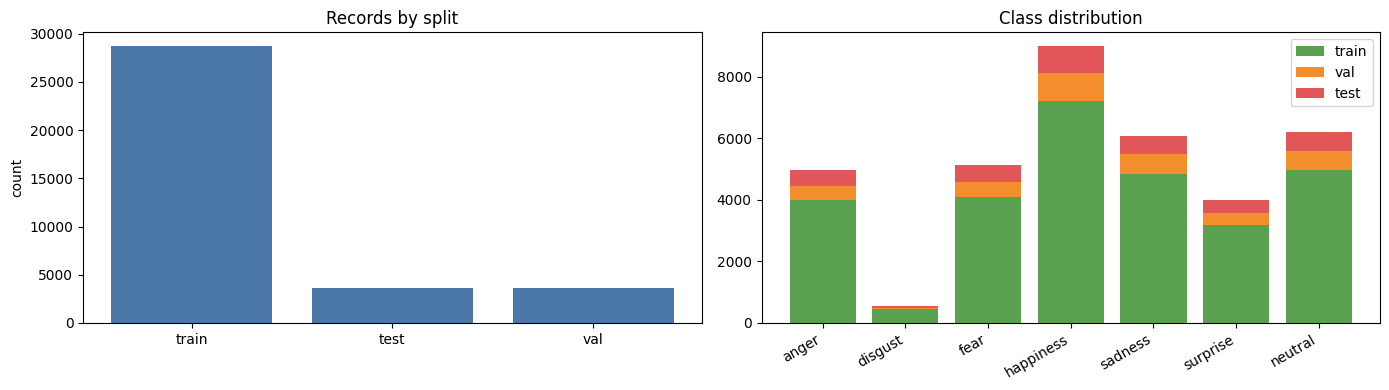

Staged: /home/jupyter-hault/EmotionCLIP-ReID/outputs/.notebook_staging/fer2013-20260722T214746.701020+0700-seed1234/visuals/fer2013_train_gallery.png


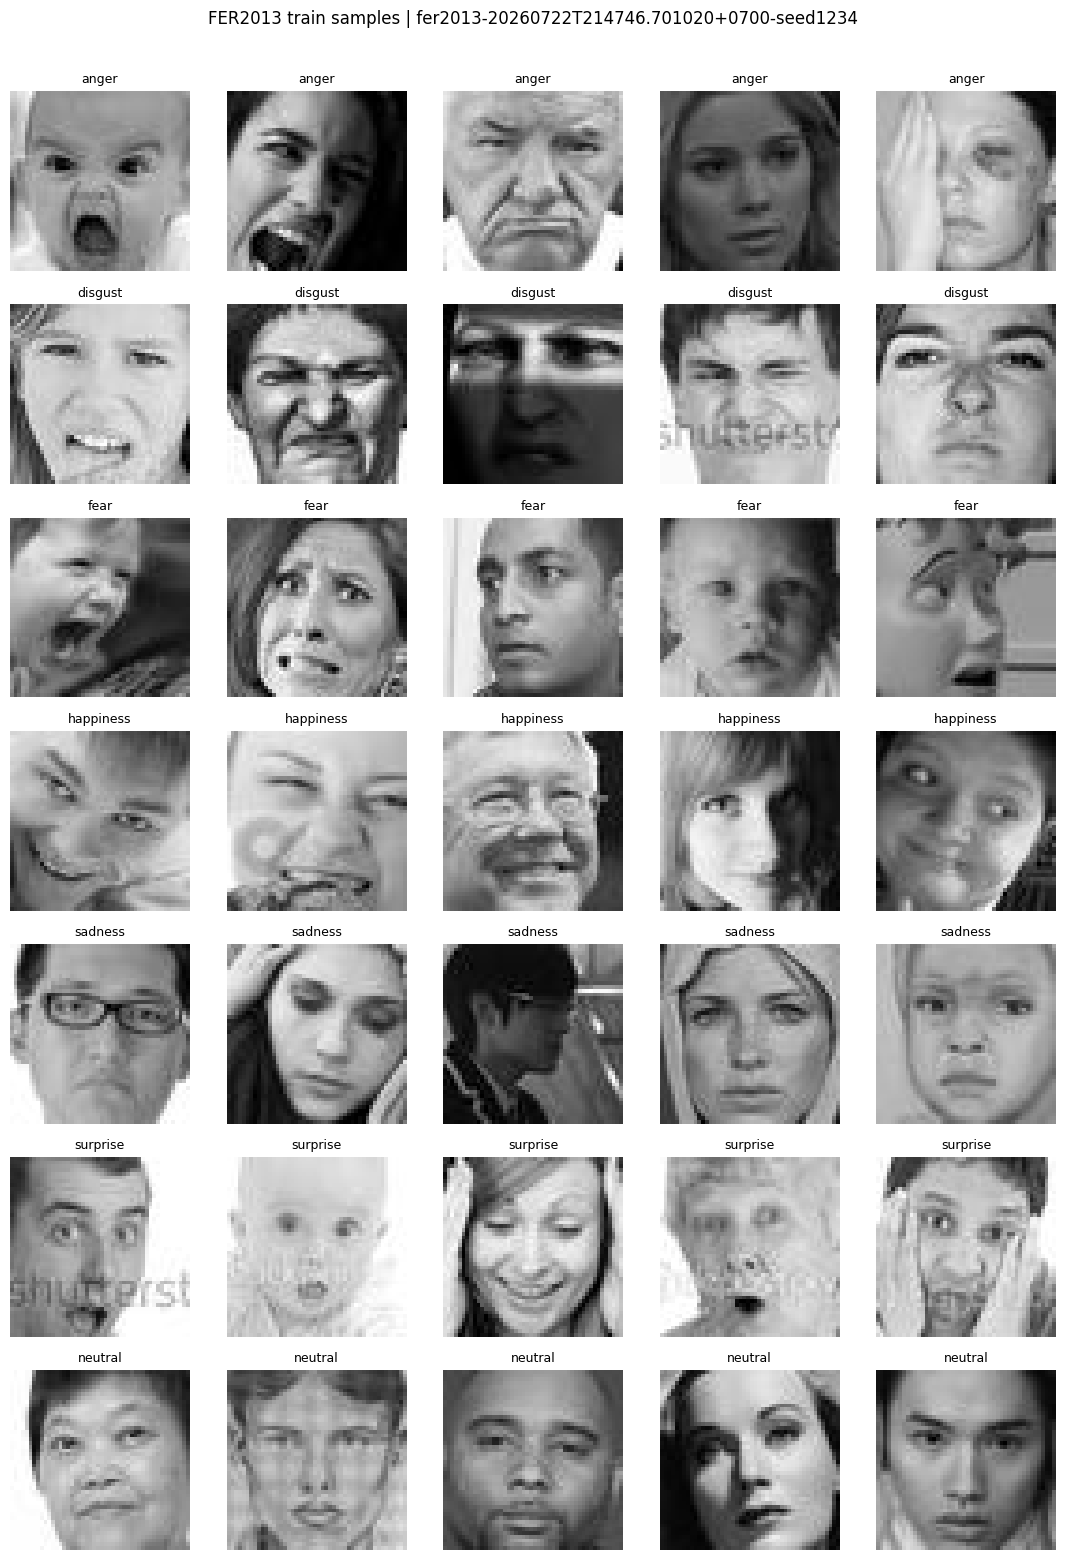

In [10]:
from collections import Counter, defaultdict
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

assert records, 'records rỗng. Hãy chạy cell download/load manifest trước.'
split_counts = Counter(r['split'] for r in records)
class_counts = Counter(r['emotion'] for r in records)
split_class_counts = defaultdict(Counter)
for record in records:
    split_class_counts[record['split']][record['emotion']] += 1

print('Total records:', len(records))
print('Splits:', split_counts)
print('Classes:', class_counts)

classes = ['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise', 'neutral']
splits = [split for split in ['train', 'val', 'test'] if split in split_counts]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(split_counts.keys(), split_counts.values(), color='#4C78A8')
axes[0].set_title('Records by split')
axes[0].set_ylabel('count')
x = range(len(classes))
bottom = [0] * len(classes)
colors = {'train': '#59A14F', 'val': '#F28E2B', 'test': '#E15759'}
for split in splits:
    values = [split_class_counts[split][emotion] for emotion in classes]
    axes[1].bar(x, values, bottom=bottom, label=split, color=colors[split])
    bottom = [base + value for base, value in zip(bottom, values)]
axes[1].set_xticks(list(x), classes, rotation=30, ha='right')
axes[1].set_title('Class distribution')
axes[1].legend()
plt.tight_layout()
distribution_path = NOTEBOOK_VISUAL_STAGE_DIR / 'fer2013_train_distribution.png'
fig.savefig(distribution_path, dpi=180, bbox_inches='tight')
print('Staged:', distribution_path)
plt.show()

samples_by_class = defaultdict(list)
for record in records:
    if record['split'] == 'train':
        samples_by_class[record['emotion']].append(record)
rng = random.Random(SEED)
cols = 5
rows = len(classes)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
for row_idx, emotion in enumerate(classes):
    candidates = samples_by_class[emotion]
    choices = rng.sample(candidates, min(cols, len(candidates)))
    for col_idx in range(cols):
        ax = axes[row_idx, col_idx]
        ax.axis('off')
        if col_idx < len(choices):
            image_path = IMAGES_ROOT / choices[col_idx]['image_path']
            ax.imshow(Image.open(image_path).convert('RGB'))
            ax.set_title(emotion, fontsize=9)
fig.suptitle(f'FER2013 train samples | {RUN_ID}', y=1.01)
plt.tight_layout()
gallery_path = NOTEBOOK_VISUAL_STAGE_DIR / 'fer2013_train_gallery.png'
fig.savefig(gallery_path, dpi=180, bbox_inches='tight')
print('Staged:', gallery_path)
plt.show()


## 2.3. Preview ảnh mẫu


{'image_path': 'train/neutral/train_000000.jpg', 'emotion': 'neutral', 'emotion_id': 6, 'split': 'train', 'source': 'Aaryan333/fer2013_train_publicTest_privateTest', 'hf_split': 'train', 'hf_index': 0}
/home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/images/train/neutral/train_000000.jpg
Staged: /home/jupyter-hault/EmotionCLIP-ReID/outputs/.notebook_staging/fer2013-20260722T214746.701020+0700-seed1234/visuals/fer2013_train_single_preview.png


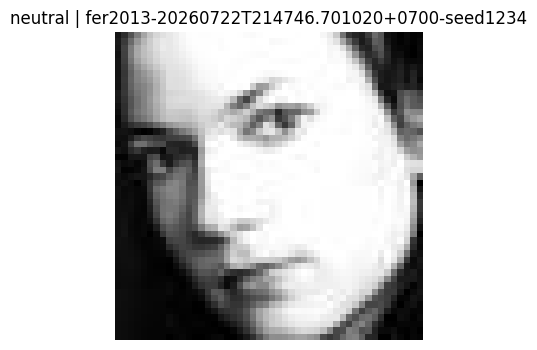

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

sample = next(record for record in records if record['split'] == 'train')
image_path = IMAGES_ROOT / sample['image_path']
print(sample)
print(image_path)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(Image.open(image_path).convert('RGB'))
ax.set_title(f"{sample['emotion']} | {RUN_ID}")
ax.axis('off')
preview_path = NOTEBOOK_VISUAL_STAGE_DIR / 'fer2013_train_single_preview.png'
fig.savefig(preview_path, dpi=180, bbox_inches='tight')
print('Staged:', preview_path)
plt.show()


## 4. Training EmotionCLIP-ReID trên 2 GPU T4

Training dùng một tiến trình `DataParallel` để chia mỗi batch Stage 2 qua hai GPU T4. `GPU_IDS` là danh sách GPU nhìn thấy bởi tiến trình; `IMS_PER_BATCH` vẫn là batch size tổng, không phải batch size trên mỗi GPU. Stage 1 chỉ dùng hai GPU ở bước trích xuất đặc trưng ảnh, còn phần tối ưu prompt nhỏ chạy trên GPU chính. Checkpoint vẫn lưu theo model gốc, không có tiền tố `module.`.

Run dùng đúng `RUN_ID` timestamp đã khóa ở trên, ghi `train.log`, CSV, checkpoint và provenance vào `OUTPUT_DIR`. Console của notebook và toàn bộ visual trước train được publish vào cùng run sau khi tiến trình đã khởi tạo thư mục immutable.


In [12]:
import subprocess
import sys
from datetime import datetime

from utils.notebook_progress import stream_process_output
from utils.notebook_run import publish_notebook_artifacts

train_cmd = [
    sys.executable, '-u', 'train_emotionclip.py',
    '--gpus', ','.join(str(gpu_id) for gpu_id in GPU_IDS),
    '--run-id', RUN_ID,
    '--config_file', CONFIG_FILE,
    *TRAIN_OVERRIDES,
]

env = os.environ.copy()
env['PYTHONUNBUFFERED'] = '1'
env['EMOTIONCLIP_PROGRESS'] = '1'
env.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
print('RUN_ID:', RUN_ID)
print('Running:', ' '.join(train_cmd), flush=True)
process = subprocess.Popen(
    train_cmd,
    cwd=REPO_DIR,
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
log_chunks = stream_process_output(process)
return_code = process.wait()
RUN_FINISHED_AT = datetime.now().astimezone()

if Path(OUTPUT_DIR).is_dir() and (Path(OUTPUT_DIR) / 'provenance.json').is_file():
    notebook_payload = publish_notebook_artifacts(
        OUTPUT_DIR,
        NOTEBOOK_STAGING_DIR,
        console_text=''.join(log_chunks),
        metadata={
            'run_id': RUN_ID,
            'started_at': RUN_STARTED_AT.isoformat(),
            'finished_at': RUN_FINISHED_AT.isoformat(),
            'return_code': return_code,
            'command': train_cmd,
            'manifest': str(ACTIVE_MANIFEST),
        },
    )
    print('Notebook artifacts:', notebook_payload['output_dir'])
else:
    failed_log = NOTEBOOK_STAGING_DIR / 'notebook_console_failed.log'
    failed_log.write_text(''.join(log_chunks), encoding='utf-8')
    print('Run chưa khởi tạo OUTPUT_DIR; console được giữ tại:', failed_log)

if return_code != 0:
    tail = ''.join(log_chunks).splitlines()[-80:]
    print('\\n'.join(tail))
    raise subprocess.CalledProcessError(return_code, train_cmd)
print('Training finished:', OUTPUT_DIR)


RUN_ID: fer2013-20260722T214746.701020+0700-seed1234
Running: /opt/tljh/user/envs/py310/bin/python -u train_emotionclip.py --gpus 0 --run-id fer2013-20260722T214746.701020+0700-seed1234 --config_file configs/emotion/vit_b16_emotionclip_hf_fer2013_quick.yml SOLVER.SEED 1234 SOLVER.STAGE1.MODE both SOLVER.STAGE1.MAX_EPOCHS 100 SOLVER.STAGE1.BASE_EPOCHS 50 SOLVER.STAGE1.GEOMETRY_EPOCHS 50 SOLVER.STAGE1.IMS_PER_BATCH 128 SOLVER.STAGE1.BASE_LR 0.00035 SOLVER.STAGE1.WEIGHT_DECAY 0.0001 SOLVER.STAGE2.MAX_EPOCHS 50 SOLVER.STAGE2.IMS_PER_BATCH 64 SOLVER.STAGE2.GRADIENT_ACCUMULATION_STEPS 2 SOLVER.STAGE2.BASE_LR 5e-06 SOLVER.STAGE2.WEIGHT_DECAY 0.0001 SOLVER.STAGE2.RELIABILITY_WARMUP_EPOCHS 20 SOLVER.STAGE2.EVAL_PERIOD 1 TEST.IMS_PER_BATCH 32 DATALOADER.NUM_WORKERS 0 DATALOADER.PIN_MEMORY false DATASETS.REQUIRE_ANATOMY true DATASETS.MIN_ANATOMY_COVERAGE 0.8 DATASETS.ALLOW_ANATOMY_FALLBACK false MODEL.ANATOMY_PROMPT.MODE quality MODEL.ROUTING.MODE hybrid MODEL.GEOMETRY.ENABLED true MODEL.UNCERTAI

2026-07-22 21:47:52,990 emotionclip.train INFO: CUDA device selected device=cuda:0 name=Tesla T4 visible_devices=2
2026-07-22 21:47:52,991 emotionclip.train INFO: Train config saved path=/home/jupyter-hault/EmotionCLIP-ReID/outputs/emotionclip_hf_fer2013_s1-100_s2-50/fer2013-20260722T214746.701020+0700-seed1234/train_config_fer2013-20260722T214746.701020+0700-seed1234.csv
2026-07-22 21:47:53,000 emotionclip.train INFO: Effective config saved path=/home/jupyter-hault/EmotionCLIP-ReID/outputs/emotionclip_hf_fer2013_s1-100_s2-50/fer2013-20260722T214746.701020+0700-seed1234/effective_config.yml sources=/home/jupyter-hault/EmotionCLIP-ReID/outputs/emotionclip_hf_fer2013_s1-100_s2-50/fer2013-20260722T214746.701020+0700-seed1234/config_sources.json precedence=defaults<yaml<notebook_or_cli stage2_micro_batch=64 stage2_effective_batch=128 stage2_per_gpu_micro_batch=64
2026-07-22 21:47:53,000 emotionclip.train INFO: Run config config_file=configs/emotion/vit_b16_emotionclip_hf_fer2013_quick.yml 

CalledProcessError: Command '['/opt/tljh/user/envs/py310/bin/python', '-u', 'train_emotionclip.py', '--gpus', '0', '--run-id', 'fer2013-20260722T214746.701020+0700-seed1234', '--config_file', 'configs/emotion/vit_b16_emotionclip_hf_fer2013_quick.yml', 'SOLVER.SEED', '1234', 'SOLVER.STAGE1.MODE', 'both', 'SOLVER.STAGE1.MAX_EPOCHS', '100', 'SOLVER.STAGE1.BASE_EPOCHS', '50', 'SOLVER.STAGE1.GEOMETRY_EPOCHS', '50', 'SOLVER.STAGE1.IMS_PER_BATCH', '128', 'SOLVER.STAGE1.BASE_LR', '0.00035', 'SOLVER.STAGE1.WEIGHT_DECAY', '0.0001', 'SOLVER.STAGE2.MAX_EPOCHS', '50', 'SOLVER.STAGE2.IMS_PER_BATCH', '64', 'SOLVER.STAGE2.GRADIENT_ACCUMULATION_STEPS', '2', 'SOLVER.STAGE2.BASE_LR', '5e-06', 'SOLVER.STAGE2.WEIGHT_DECAY', '0.0001', 'SOLVER.STAGE2.RELIABILITY_WARMUP_EPOCHS', '20', 'SOLVER.STAGE2.EVAL_PERIOD', '1', 'TEST.IMS_PER_BATCH', '32', 'DATALOADER.NUM_WORKERS', '0', 'DATALOADER.PIN_MEMORY', 'false', 'DATASETS.REQUIRE_ANATOMY', 'true', 'DATASETS.MIN_ANATOMY_COVERAGE', '0.8', 'DATASETS.ALLOW_ANATOMY_F

In [ ]:
from pathlib import Path
from utils.notebook_metrics import load_validation_metrics, print_validation_summary

RUN_VISUAL_DIR = Path(OUTPUT_DIR) / 'visuals'
RUN_VISUAL_DIR.mkdir(parents=True, exist_ok=True)
validation_metrics = load_validation_metrics(
    candidate_output_dirs=[Path(OUTPUT_DIR)],
    csv_candidates=[Path(OUTPUT_DIR) / 'validation_metrics.csv'],
    summary_candidates=[Path(OUTPUT_DIR) / 'best_metrics_summary.json'],
    uncertainty_candidates=[Path(OUTPUT_DIR) / 'uncertainty_summary.json'],
)
RESULT_DIR = validation_metrics['result_dir']
metric_files = validation_metrics['metric_files']
metric_history = validation_metrics['metric_history']
metrics_by_epoch = validation_metrics['metrics_by_epoch']
metrics_latest = validation_metrics['metrics_latest']
metrics_best = validation_metrics['metrics_best']
best_metric = validation_metrics['best_metric']
print('RUN_ID:', RUN_ID)
print('OUTPUT_DIR:', Path(OUTPUT_DIR))
print_validation_summary(validation_metrics)


### 4.2 Biểu đồ metric validation theo epoch

In [ ]:
from utils.notebook_metrics import plot_validation_metric_curves

validation_visuals = dict(validation_metrics)
validation_visuals['result_dir'] = RUN_VISUAL_DIR
plot_validation_metric_curves(validation_visuals, dataset_name='FER2013', file_prefix='fer2013')


### 4.3 Biểu đồ loss/accuracy training từ log

In [ ]:
from utils.notebook_metrics import load_training_history, plot_training_metric_curves

training_history, training_source = load_training_history(
    [Path(OUTPUT_DIR)],
    csv_candidates=[Path(OUTPUT_DIR) / 'training_epoch_losses.csv'],
)
plot_training_metric_curves(
    training_history, training_source, RUN_VISUAL_DIR, file_prefix='fer2013'
)


### 4.4 Confusion matrix và per-class F1

In [ ]:
from utils.notebook_metrics import plot_confusion_matrix_and_f1

plot_confusion_matrix_and_f1(
    validation_visuals, dataset_name='FER2013', file_prefix='fer2013'
)


## 5. Xem metrics và infer một ảnh

In [ ]:
from pathlib import Path
from utils.notebook_metrics import (
    load_validation_metrics,
    plot_confusion_matrix_and_f1,
    plot_validation_metric_curves,
    print_validation_summary,
)

current_output = Path(OUTPUT_DIR)
is_rafdb_output = "raf" in current_output.as_posix().lower()
active_dataset_name = "RAF-DB" if is_rafdb_output else "FER2013"
active_file_prefix = "rafdb" if is_rafdb_output else "fer2013"

if is_rafdb_output:
    candidate_output_dirs = [
        current_output,
    ]
    csv_candidates = []
    summary_candidates = []
    uncertainty_candidates = []
else:
    candidate_output_dirs = [
        current_output,
    ]
    csv_candidates = [
        current_output / "validation_metrics.csv",
    ]
    summary_candidates = [
        current_output / "best_metrics_summary.json",
    ]
    uncertainty_candidates = [
        current_output / "uncertainty_summary.json",
    ]

validation_metrics = load_validation_metrics(
    candidate_output_dirs=candidate_output_dirs,
    csv_candidates=csv_candidates,
    summary_candidates=summary_candidates,
    uncertainty_candidates=uncertainty_candidates,
)
RESULT_DIR = validation_metrics["result_dir"]
metric_files = validation_metrics["metric_files"]
metric_history = validation_metrics["metric_history"]
metrics_by_epoch = validation_metrics["metrics_by_epoch"]
metrics_latest = validation_metrics["metrics_latest"]
metrics_best = validation_metrics["metrics_best"]
best_metric = validation_metrics["best_metric"]

print_validation_summary(validation_metrics)
plot_validation_metric_curves(validation_metrics, dataset_name=active_dataset_name, file_prefix=active_file_prefix)
plot_confusion_matrix_and_f1(validation_metrics, dataset_name=active_dataset_name, file_prefix=active_file_prefix)

In [ ]:
import subprocess
import sys

val_records = [record for record in records if record['split'] == 'val']
infer_record = val_records[0] if val_records else records[0]
infer_image = IMAGES_ROOT / infer_record['image_path']
infer_weight = Path(OUTPUT_DIR) / 'best_emotionclip.pth'
assert infer_weight.is_file(), f'Không thấy checkpoint trong run {RUN_ID}: {infer_weight}'
print('ground truth:', infer_record)
print('image:', infer_image)
subprocess.check_call([
    sys.executable,
    'infer_emotionclip.py',
    '--config_file', CONFIG_FILE,
    '--weight', str(infer_weight),
    '--image', str(infer_image),
])


## 5.2. Visual kết quả từng bước

Cell dưới trực quan hóa pipeline trên một vài ảnh validation: ảnh gốc → ảnh sau transform 224x224 → ground truth/prediction → biểu đồ xác suất 7 emotion → descriptor similarity → uncertainty. Chạy sau khi đã có `best_emotionclip.pth` trong `OUTPUT_DIR`.

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

from config.emotion_defaults import load_emotion_cfg
from datasets.emotion_manifest import CANONICAL_EMOTIONS, FaceSafeTransform
from model.emotionclip_model import EmotionCLIPModel
from processor.processor_emotionclip import load_emotion_checkpoint

ckpt_path = Path(OUTPUT_DIR) / 'best_emotionclip.pth'
assert ckpt_path.exists(), f'Không thấy checkpoint: {ckpt_path}. Hãy chạy training trước.'
val_records = [r for r in records if r['split'] == 'val']
assert val_records, 'Không có val records để visualize.'
N_VIS = min(6, len(val_records))
vis_records = random.sample(val_records, N_VIS)

cfg = load_emotion_cfg(CONFIG_FILE, [])
if cfg['MODEL']['DEVICE'] == 'cuda' and not torch.cuda.is_available():
    cfg['MODEL']['DEVICE'] = 'cpu'
device = torch.device(cfg['MODEL']['DEVICE'])
model_cfg = cfg['MODEL']['EMOTION']
model = EmotionCLIPModel(
    class_names=CANONICAL_EMOTIONS,
    backbone_name=cfg['MODEL']['NAME'],
    image_size=cfg['INPUT']['SIZE_TEST'],
    stride_size=cfg['MODEL']['STRIDE_SIZE'],
    n_ctx=int(model_cfg['N_CTX']),
    adapter_dim=int(model_cfg['ADAPTER_DIM']),
    adapter_dropout=float(model_cfg['ADAPTER_DROPOUT']),
    topk_patches=int(model_cfg['TOPK_PATCHES']),
    global_weight=float(model_cfg['GLOBAL_WEIGHT']),
    local_weight=float(model_cfg['LOCAL_WEIGHT']),
    classifier_weight=float(model_cfg['CLASSIFIER_WEIGHT']),
    train_last_blocks=int(model_cfg['TRAIN_LAST_BLOCKS']),
)
load_emotion_checkpoint(model, str(ckpt_path), strict=False)
model.to(device).eval()
transform = FaceSafeTransform(
    size=tuple(cfg['INPUT']['SIZE_TEST']),
    train=False,
    mean=cfg['INPUT']['PIXEL_MEAN'],
    std=cfg['INPUT']['PIXEL_STD'],
)

mean = np.array(cfg['INPUT']['PIXEL_MEAN']).reshape(3, 1, 1)
std = np.array(cfg['INPUT']['PIXEL_STD']).reshape(3, 1, 1)
def denorm(tensor):
    arr = tensor.detach().cpu().numpy()
    arr = np.clip(arr * std + mean, 0, 1)
    return np.transpose(arr, (1, 2, 0))

fig, axes = plt.subplots(N_VIS, 4, figsize=(18, 4 * N_VIS))
if N_VIS == 1:
    axes = np.expand_dims(axes, 0)

for row, rec in enumerate(vis_records):
    image_path = Path(IMAGES_ROOT) / rec['image_path']
    image = Image.open(image_path).convert('RGB')
    tensor = transform(image)
    with torch.no_grad():
        outputs = model(images=tensor.unsqueeze(0).to(device))
    probs = outputs['probabilities'][0].detach().cpu().numpy()
    sims = outputs['alignment_logits'][0].detach().cpu().numpy()
    uncertainty = float(outputs['uncertainty'][0].detach().cpu())
    pred_id = int(probs.argmax())
    pred_name = CANONICAL_EMOTIONS[pred_id]
    gt_name = rec['emotion']
    ok = pred_name == gt_name

    axes[row, 0].imshow(image, cmap='gray')
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f'Original\nGT: {gt_name}')

    axes[row, 1].imshow(denorm(tensor))
    axes[row, 1].axis('off')
    axes[row, 1].set_title('After FaceSafeTransform\n224x224 + CLIP norm')

    colors = ['#59A14F' if name == gt_name else '#E15759' if name == pred_name else '#4C78A8' for name in CANONICAL_EMOTIONS]
    axes[row, 2].barh(list(CANONICAL_EMOTIONS), probs, color=colors)
    axes[row, 2].set_xlim(0, max(0.35, float(probs.max()) + 0.05))
    axes[row, 2].invert_yaxis()
    axes[row, 2].set_title(f'Probabilities\nPred: {pred_name} ({probs[pred_id]:.3f})\nunc={uncertainty:.3f} | correct={ok}')

    axes[row, 3].barh(list(CANONICAL_EMOTIONS), sims, color='#F28E2B')
    axes[row, 3].invert_yaxis()
    axes[row, 3].set_title('Descriptor similarity\nimage-text alignment logits')

plt.tight_layout()
pipeline_path = RUN_VISUAL_DIR / 'fer2013_pipeline_examples.png'
fig.savefig(pipeline_path, dpi=180, bbox_inches='tight')
print('Saved:', pipeline_path)
plt.show()


## 6. AU support scaffold

Cell này chỉ là cầu nối giải thích dựa trên AU điển hình, chưa phải nhánh AU trainable. Để biến thành nhánh AU hỗ trợ thật, cần thêm AU detector/pseudo-label hoặc dataset có AU thật, sau đó sửa `EmotionCLIPModel` và `emotion_stage2_loss` để dùng `au_labels` bằng BCE/multi-task loss.

In [ ]:
AU_HINTS = {
    'happiness': ['AU6 cheek raiser', 'AU12 lip corner puller'],
    'sadness': ['AU1 inner brow raiser', 'AU4 brow lowerer', 'AU15 lip corner depressor'],
    'surprise': ['AU1 inner brow raiser', 'AU2 outer brow raiser', 'AU5 upper lid raiser', 'AU26 jaw drop'],
    'fear': ['AU1 inner brow raiser', 'AU2 outer brow raiser', 'AU4 brow lowerer', 'AU5 upper lid raiser', 'AU20 lip stretcher'],
    'anger': ['AU4 brow lowerer', 'AU5 upper lid raiser', 'AU7 lid tightener', 'AU23 lip tightener'],
    'disgust': ['AU9 nose wrinkler', 'AU10 upper lip raiser'],
    'neutral': ['low-intensity or no dominant AU evidence'],
}

def explain_emotion_with_au(emotion):
    return AU_HINTS.get(emotion, [])

print('Example AU hints for ground truth:', infer_record['emotion'], explain_emotion_with_au(infer_record['emotion']))